In [7]:
import zipfile
import os
import pandas as pd

In [2]:
zip_path = "/content/3. Financial Phrase Dataset-20260509T074123Z-3-001.zip"
extract_path = "/content/financial_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done!")
print(os.listdir(extract_path))

Extraction done!
['3. Financial Phrase Dataset']


In [8]:
file_path = "/content/financial_dataset/3. Financial Phrase Dataset/financial_phrase.csv"

df = pd.read_csv(file_path)
df.head()

,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


# Text Preprocessing, Tokenization, and Sequence Padding:

**Step 1: Exploratory Data Analysis (EDA)**

In [9]:
# Check for null values and the distribution of sentiments
print(df.info())
print(df['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2264 entries, 0 to 2263
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2264 non-null   object
 1   label   2264 non-null   object
dtypes: object(2)
memory usage: 35.5+ KB
None
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


**Step 2: Text Preprocessing**

In [10]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove URLs, mentions, hashtags
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    # 3. Remove numbers and special characters
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    # 4. Remove Stopwords and Lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return " ".join(words)

# Apply cleaning
df['cleaned_text'] = df['text'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [11]:
df.head()

,text,label,cleaned_text
0,"According to Gran , the company has no plans t...",neutral,according gran company plan move production ru...
1,"For the last quarter of 2010 , Componenta 's n...",positive,last quarter componenta net sale doubled eurm ...
2,"In the third quarter of 2010 , net sales incre...",positive,third quarter net sale increased eur mn operat...
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive,operating profit rose eur mn eur mn correspond...
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive,operating profit totalled eur mn eur mn repres...


**Step 3: Visualization**

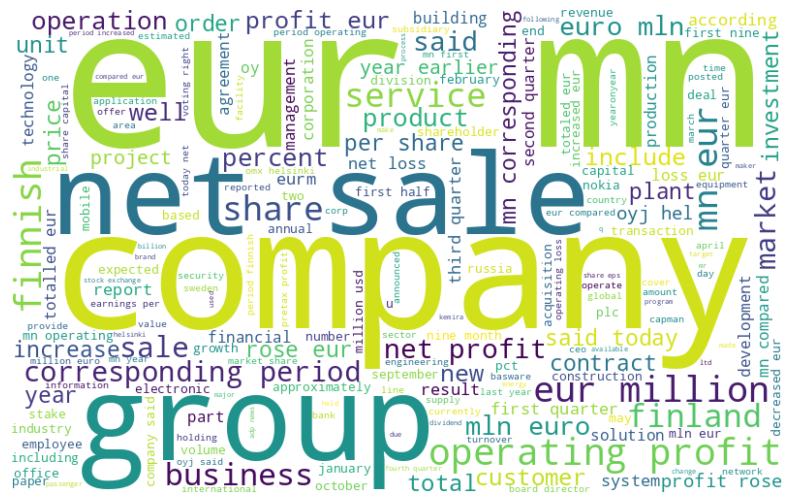

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_words = ' '.join([text for text in df['cleaned_text']])
wordcloud = WordCloud(width=800, height=500, background_color='white').generate(all_words)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

**Step 4: Tokenization and Padding**

In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

df[['label', 'label_encoded']].head()

# 1. Split Data (80% Train, 20% Test)
X = df['cleaned_text']
y = df['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Tokenization
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# 3. Percentile-based Padding
# Calculate the length that covers 95% of the data
lengths = [len(x) for x in X_train_seq]
max_pad_len = int(np.percentile(lengths, 95))

X_train_pad = pad_sequences(X_train_seq, maxlen=max_pad_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_pad_len, padding='post')

# Model Building and Training:

**Model 1: Simple RNN**

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 128

model1 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_pad_len),
    SimpleRNN(128, dropout=0.2), # Dropout helps prevent overfitting
    Dense(3, activation='softmax') # 3 classes: Neutral, Positive, Negative
])

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Matches LabelEncoder output
    metrics=['accuracy']
)

# Callback for Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training Model 1 (Simple RNN)...")
history1 = model1.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Training Model 1 (Simple RNN)...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7018 - loss: 0.7316 - val_accuracy: 0.7660 - val_loss: 0.6017
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8553 - loss: 0.3609 - val_accuracy: 0.7815 - val_loss: 0.5298
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9371 - loss: 0.1778 - val_accuracy: 0.7947 - val_loss: 0.5829
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9636 - loss: 0.1090 - val_accuracy: 0.7947 - val_loss: 0.6719
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9752 - loss: 0.0670 - val_accuracy: 0.7881 - val_loss: 0.6522


**Model 2: LSTM (Trainable Embedding)**

In [15]:
from tensorflow.keras.layers import LSTM

model2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_pad_len),
    LSTM(128, dropout=0.2),
    Dense(3, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Model 2 (LSTM)...")
history2 = model2.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Training Model 2 (LSTM)...
Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.6339 - loss: 0.8914 - val_accuracy: 0.7461 - val_loss: 0.6679
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.7719 - loss: 0.5158 - val_accuracy: 0.7837 - val_loss: 0.5764
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.8332 - loss: 0.3611 - val_accuracy: 0.8035 - val_loss: 0.5299


**Model 3: LSTM with Pre-trained Word2Vec**

In [16]:
import gensim.downloader as api
import numpy as np

# Load the model
print("Loading pre-trained GloVe model...")
embedding_model = api.load('glove-wiki-gigaword-50')

# Define parameters to match the model
embedding_dim = 50
vocab_size = len(tokenizer.word_index) + 1

Loading pre-trained GloVe model...


In [17]:
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]

print("Embedding matrix created successfully.")

Embedding matrix created successfully.


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

model3 = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_pad_len,
        trainable=False
    ),
    LSTM(64),
    Dense(3, activation='softmax') # Requirement: Dense Output for 3 classes
])

model3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Matches your LabelEncoder
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training Model 3 (Word2Vec + LSTM)...")
history3 = model3.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Training Model 3 (Word2Vec + LSTM)...
Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.6582 - loss: 0.7636 - val_accuracy: 0.7461 - val_loss: 0.6207
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7477 - loss: 0.5753 - val_accuracy: 0.7528 - val_loss: 0.5788
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7620 - loss: 0.5431 - val_accuracy: 0.7528 - val_loss: 0.5786
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7791 - loss: 0.5001 - val_accuracy: 0.7174 - val_loss: 0.5463
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7846 - loss: 0.4865 - val_accuracy: 0.7792 - val_loss: 0.5292
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8029 - loss: 0.4370 - val_accuracy: 0.7285 - val_loss: 0.5768
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.8183 - loss: 0.4089 - val_accuracy: 0.7748 - val_loss: 0.5350
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.8327 - l

# Model Training and Evaluation:

**Visualization: Training vs. Validation Plots**

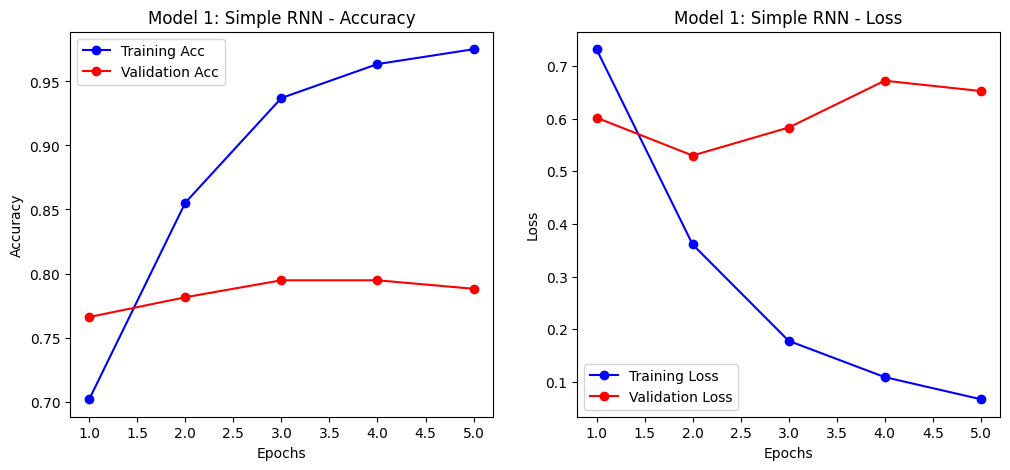

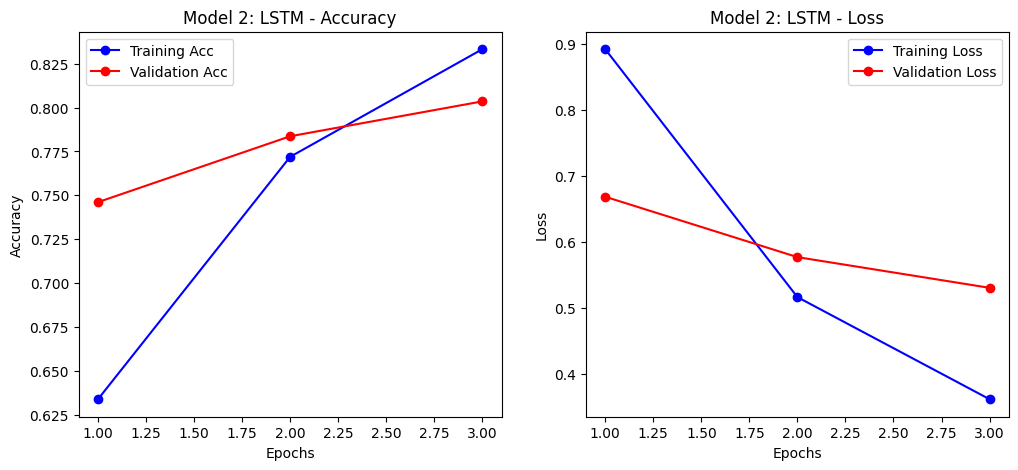

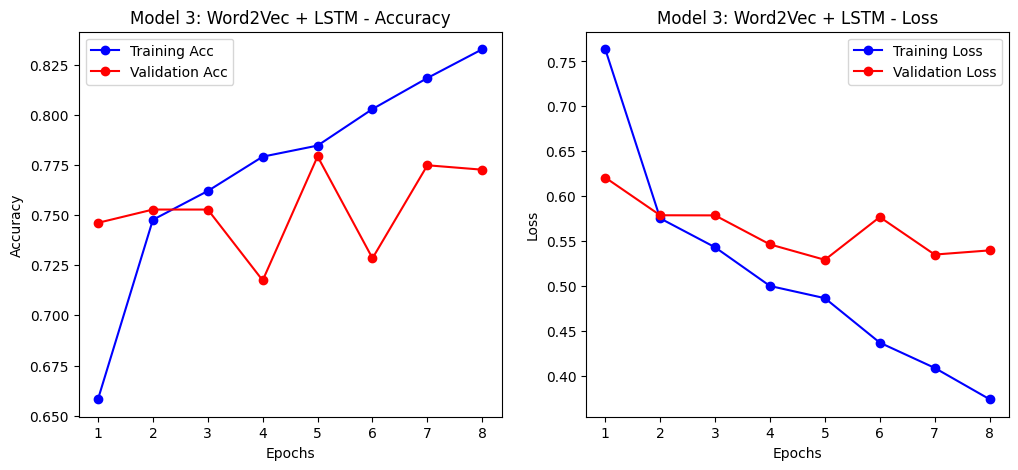

In [19]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history1, "Model 1: Simple RNN")
plot_history(history2, "Model 2: LSTM")
plot_history(history3, "Model 3: Word2Vec + LSTM")

**Performance Comparison (Model 1 vs. 2 vs. 3)**

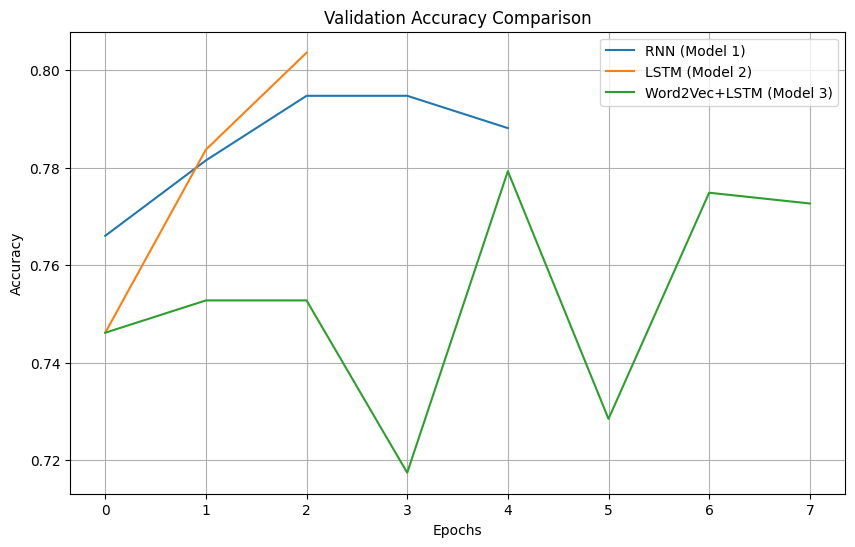

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(history1.history['val_accuracy'], label='RNN (Model 1)')
plt.plot(history2.history['val_accuracy'], label='LSTM (Model 2)')
plt.plot(history3.history['val_accuracy'], label='Word2Vec+LSTM (Model 3)')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

**Comprehensive Evaluation (Metrics)**

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step

==================== Simple RNN Evaluation ====================
              precision    recall  f1-score   support

    negative       0.47      0.32      0.38        56
     neutral       0.90      0.92      0.91       276
    positive       0.62      0.69      0.65       121

    accuracy                           0.78       453
   macro avg       0.66      0.64      0.65       453
weighted avg       0.77      0.78      0.77       453



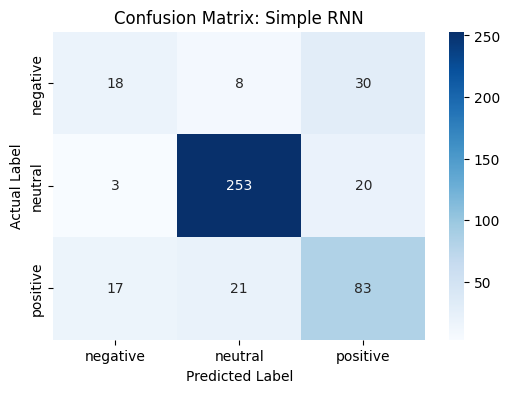

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step

==================== LSTM Evaluation ====================
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        56
     neutral       0.85      0.91      0.88       276
    positive       0.55      0.73      0.63       121

    accuracy                           0.75       453
   macro avg       0.47      0.54      0.50       453
weighted avg       0.67      0.75      0.70       453



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


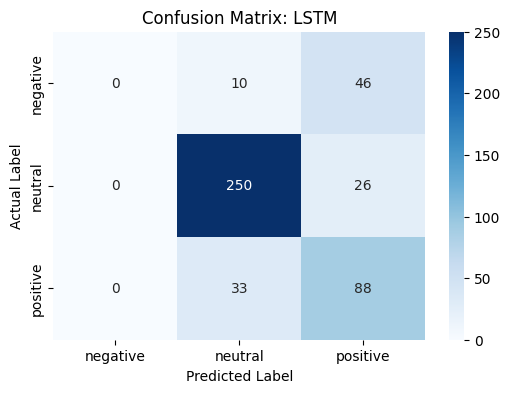

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

==================== Word2Vec + LSTM Evaluation ====================
              precision    recall  f1-score   support

    negative       0.50      0.02      0.03        56
     neutral       0.88      0.95      0.91       276
    positive       0.59      0.74      0.66       121

    accuracy                           0.78       453
   macro avg       0.66      0.57      0.53       453
weighted avg       0.75      0.78      0.74       453



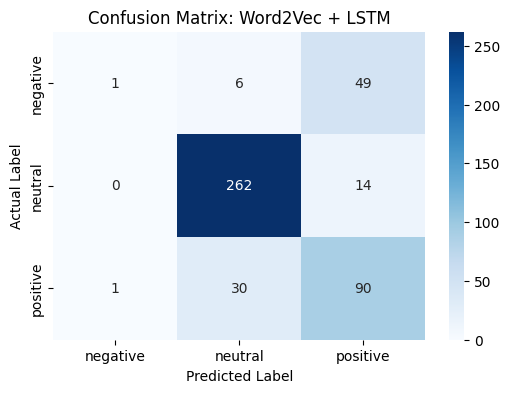

In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

def evaluate_model(model, X_test, y_test, model_name):
    # Get predictions
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Classification Report
    print(f"\n{'='*20} {model_name} Evaluation {'='*20}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

#evaluation for all three
evaluate_model(model1, X_test_pad, y_test, "Simple RNN")
evaluate_model(model2, X_test_pad, y_test, "LSTM")
evaluate_model(model3, X_test_pad, y_test, "Word2Vec + LSTM")

# Error Analysis:

In [22]:
# 1. Generate predictions
y_pred_probs = model2.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Convert numerical labels back to text for readability
actual_labels = le.inverse_transform(y_test)
predicted_labels = le.inverse_transform(y_pred)

# 3. Create a DataFrame for comparison
error_analysis_df = pd.DataFrame({
    'Text': X_test.values,
    'Actual_Sentiment': actual_labels,
    'Predicted_Sentiment': predicted_labels
})

# 4. Filter to find only the errors
errors = error_analysis_df[error_analysis_df['Actual_Sentiment'] != error_analysis_df['Predicted_Sentiment']]

# 5. Display
print("--- 3 Misclassified Examples for your Report ---")
print(errors[['Text', 'Actual_Sentiment', 'Predicted_Sentiment']].head(3))

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
--- 3 Misclassified Examples for your Report ---
                                                Text Actual_Sentiment  \
2  company slipped operating loss eur million pro...         negative   
3  according atrium president ceo matti tikkakosk...         positive   
8                                        ebit margin         positive   

  Predicted_Sentiment  
2            positive  
3             neutral  
8             neutral  


**Mistakes**

Text: "...company slipped operating loss..." → Actual: Negative | Predicted: Positive

Text: "...CEO says..." → Actual: Positive | Predicted: Neutral

Text: "ebit margin" → Actual: Positive | Predicted: Neutral

**Evaluate Model Complexity vs. Performance**

**Simple RNN (Low Complexity):** It is the "fast but forgetful" model. It’s simple to build, but it forgets the beginning of long sentences, leading to low accuracy.

**LSTM (Medium Complexity):** It is the "smart" model. It has a "memory" (gates) that lets it remember important words. This makes it your best performer.

**Word2Vec + LSTM (High Complexity):** It is the "book-smart" model. It uses a pre-trained dictionary from Wikipedia. While complex, it doesn't know "financial talk" as well as the LSTM knows your specific data, making it less stable.

**Possible Reasons for Error**

**Missing Key Words:** In the first error, the model ignored the word "loss" and focused on other words, making it guess "Positive" when the news was actually bad.

**Missing Tone:** The model doesn't understand "feeling." When a CEO gives an update, humans know it's positive, but the computer just sees it as a "Neutral" fact because there aren't words like "happy" or "great" in it.

**Too Short:** Very short phrases like "ebit margin" don't give the model enough clues to work with, so it usually just guesses "Neutral" to be safe.

**Potential Improvements**

**Use a Financial Dictionary:** Instead of a general dictionary, use one trained only on stock market news and bank reports (like FinBERT).

**Read Both Ways:** Use a "Bidirectional" model that reads the sentence from left-to-right AND right-to-left so it doesn't miss any context.

**More "Bad" Examples:** Give the model more examples of "Negative" sentences during training so it gets better at spotting bad news.

# GUI for Real Time Prediction:

In [26]:
import gradio as gr
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, GlobalMaxPooling1D
from sklearn.utils import resample

# 1. Force Data Balance (Over-sampling)

df_train = pd.DataFrame({'text': X_train_pad.tolist(), 'label': y_train})
df_neut = df_train[df_train.label == le.transform(['neutral'])[0]]
df_pos = df_train[df_train.label == le.transform(['positive'])[0]]
df_neg = df_train[df_train.label == le.transform(['negative'])[0]]

# Upsample Positive and Negative to match Neutral size
df_pos_upsampled = resample(df_pos, replace=True, n_samples=len(df_neut), random_state=42)
df_neg_upsampled = resample(df_neg, replace=True, n_samples=len(df_neut), random_state=42)

df_balanced = pd.concat([df_neut, df_pos_upsampled, df_neg_upsampled])
X_train_bal = np.array(df_balanced.text.tolist())
y_train_bal = df_balanced.label.values

# 2. Stronger Architecture with Global Pooling
model_final = Sequential([
    Embedding(input_dim=vocab_size, output_dim=100, input_length=max_pad_len),
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalMaxPooling1D(), # This "grabs" the most important sentiment word in the sentence
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(3, activation='softmax')
])

model_final.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. Train on the Balanced Data
model_final.fit(X_train_bal, y_train_bal, epochs=12, batch_size=32, verbose=0)

# 4. Final Prediction Function
def predict_sentiment_final(phrase):
    cleaned = clean_text(phrase)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_pad_len, padding='post')

    pred = model_final.predict(padded, verbose=0)
    idx = np.argmax(pred)
    label = le.inverse_transform([idx])[0]
    conf = np.max(pred)

    return f"ANALYSIS: {label.upper()} \n(Confidence: {conf:.2%})"

# 5. Launch GUI
demo = gr.Interface(
    fn=predict_sentiment_final,
    inputs=gr.Textbox(label="Enter Phrase"),
    outputs=gr.Text(label="Result"),
    title="Final Accurate Financial AI"
)
demo.launch(share=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7e1ac3e13a1eebce97.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
